In [15]:
from matplotlib import pyplot as plot
from scipy.spatial import KDTree
import numpy as np 
import pandas as pd 
import os
print(os.getcwd())

import sys
sys.path.append("..")

from utils.animation import custom_n_colormap

/vast/palmer/home.grace/kd766/quorum-sensing/notebooks


In [16]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 10  # Default font size for general text
mpl.rcParams['axes.labelsize'] = 11 # Font size for axis labels
mpl.rcParams['xtick.labelsize'] = 9 # Font size for x-axis tick labels
mpl.rcParams['ytick.labelsize'] = 9 # Font size for y-axis tick labels
mpl.rcParams['legend.fontsize'] = 9 # Font size for legend
mpl.rcParams['axes.titlesize'] = 11 # Font size for plot title

In [17]:
def slide_window(mat, ref_mat, neighbor_thresh=10):
	"""
	go cell-to-cell and find neighbors, instead of sliding the window everywhere
	- neighbor_thresh: how far another cell can be to be considered a neighbor.
	"""
	assert mat.shape==ref_mat.shape, "matrix and ref. matrix should have the same shape."
	
	# stats to collect.
	means_l = []
	stdevs_l = []
	n_cells_l = [] 
	# locate positions of cells.
	cell_posns = np.nonzero(ref_mat)
	# iteration helpers.
	r = neighbor_thresh		# shorthand.
	x_max, y_max = [dim-1 for dim in mat.shape]
	windows_l = []
	for posn_x, posn_y in zip(*cell_posns):
		# get window -- region of interest.
		top, bottom = max(0, posn_x-r), min(x_max, posn_x+r)	# rows.
		left, right = max(0, posn_y-r), min(y_max, posn_y+r)	# cols.
		mat_window = mat[top:bottom+1, left:right+1]
		ref_mat_window = ref_mat[top:bottom+1, left:right+1]
		# find locations of cells, and pick the values at those positions.
		# vals = mat_window[np.nonzero(ref_mat_window)].flatten()
		vals = mat_window.flatten()		# use all posns; not just where cells are.
		# store stats.
		n_cells_l.append(len(vals))
		means_l.append(np.mean(vals, where=(vals!=0)))		# compute using non-zero values only.
		stdevs_l.append(np.std(vals, where=(vals!=0)))		# compute using non-zero values only.
		windows_l.append(((left, top), right-left, bottom-top))

	# return stats.
	return (means_l, stdevs_l, n_cells_l)


def slide_window_using_tree(mat, ref_mat, n_neighbors=10):

    assert mat.shape==ref_mat.shape, "matrix and ref. matrix should have the same shape."
    
    # construct a KD tree of cell positions.
    cell_posns = np.array(tuple(zip(*np.nonzero(ref_mat))))
    tree = KDTree(cell_posns)
    # include the cell itself at index 0.
    dists, indices = tree.query(cell_posns, k=n_neighbors+1)
    # find the enclosing areas on the matrix.
    window_minmax_coords = [(np.min(np.squeeze(arr), axis=1), np.max(np.squeeze(arr), axis=1)) 
        for arr in np.split(np.array(cell_posns[indices]), 2, axis=-1)]
    # collect stats for all neighborhoods.
    covs_l = []
    dists_l = []
    for idx, (min_x, max_x, min_y, max_y) in enumerate(zip(*(window_minmax_coords[0] + window_minmax_coords[1]))):
        mat_window = mat[min_x:max_x+1, min_y:max_y+1]
        ref_mat_window = ref_mat[min_x:max_x+1, min_y:max_y+1]
        # find locations of cells, and pick the values at those positions.
        # vals = mat_window[np.nonzero(ref_mat_window)].flatten()
        vals = mat_window.flatten()		# use all posns; not just where cells are.
        # store stats.
        mean = np.mean(vals, where=(vals!=0))		# compute using non-zero values only.
        stdev = np.std(vals, where=(vals!=0))		# compute using non-zero values only.
        covs_l.append(stdev / mean)
        dists_l.append(np.mean(dists[idx, 1:])) 
        
    return (covs_l, dists_l, n_neighbors)

In [79]:
# file names of `clouds` file is extrapolated based on these file paths as well.
levels_withneg_l = [
	"/home/kd766/quorum-sensing/outputs/04112025064926_size-100x100_select-0.3_seed-0.025/04112025064926_size-100x100_select-0.3_seed-0.025_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025214226_size-100x100_select-0.8_seed-0.03/06262025214226_size-100x100_select-0.8_seed-0.03_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/04112025064724_size-100x100_select-0.3_seed-0.0333/04112025064724_size-100x100_select-0.3_seed-0.0333_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025214211_size-100x100_select-0.8_seed-0.05/06262025214211_size-100x100_select-0.8_seed-0.05_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025212917_size-100x100_select-1_seed-0.0667/05292025212917_size-100x100_select-1_seed-0.0667_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180028_size-100x100_select-0.3_seed-0.1/05292025180028_size-100x100_select-0.3_seed-0.1_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180016_size-100x100_select-0.3_seed-0.125/05292025180016_size-100x100_select-0.3_seed-0.125_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025174657_size-100x100_select-0.4_seed-0.15/05292025174657_size-100x100_select-0.4_seed-0.15_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180030_size-100x100_select-0.3_seed-0.175/05292025180030_size-100x100_select-0.3_seed-0.175_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/05292025180015_size-100x100_select-0.3_seed-0.2/05292025180015_size-100x100_select-0.3_seed-0.2_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025142707_size-100x100_select-0.3_seed-0.225/06262025142707_size-100x100_select-0.3_seed-0.225_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025142751_size-100x100_select-0.3_seed-0.25/06262025142751_size-100x100_select-0.3_seed-0.25_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/06262025142714_size-100x100_select-0.3_seed-0.275/06262025142714_size-100x100_select-0.3_seed-0.275_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025064439_size-100x100_select-0.4_seed-0.3/12072025064439_size-100x100_select-0.4_seed-0.3_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025064652_size-100x100_select-0.4_seed-0.325/12072025064652_size-100x100_select-0.4_seed-0.325_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025064721_size-100x100_select-0.4_seed-0.35/12072025064721_size-100x100_select-0.4_seed-0.35_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025064721_size-100x100_select-0.4_seed-0.375/12072025064721_size-100x100_select-0.4_seed-0.375_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025071240_size-100x100_select-0.4_seed-0.4/12072025071240_size-100x100_select-0.4_seed-0.4_levels_final.csv",
]

levels_noneg_l = [
	"/home/kd766/quorum-sensing/outputs/07232025152722_size-100x100_select-0.3_seed-0.025_noneg/07232025152722_size-100x100_select-0.3_seed-0.025_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025162644_size-100x100_select-0.3_seed-0.03_noneg/07232025162644_size-100x100_select-0.3_seed-0.03_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152745_size-100x100_select-0.3_seed-0.0333_noneg/07232025152745_size-100x100_select-0.3_seed-0.0333_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025162614_size-100x100_select-0.3_seed-0.05_noneg/07232025162614_size-100x100_select-0.3_seed-0.05_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152552_size-100x100_select-0.3_seed-0.0667_noneg/07232025152552_size-100x100_select-0.3_seed-0.0667_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152554_size-100x100_select-0.3_seed-0.1_noneg/07232025152554_size-100x100_select-0.3_seed-0.1_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152556_size-100x100_select-0.3_seed-0.125_noneg/07232025152556_size-100x100_select-0.3_seed-0.125_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152621_size-100x100_select-0.3_seed-0.15_noneg/07232025152621_size-100x100_select-0.3_seed-0.15_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152648_size-100x100_select-0.3_seed-0.175_noneg/07232025152648_size-100x100_select-0.3_seed-0.175_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025152708_size-100x100_select-0.3_seed-0.2_noneg/07232025152708_size-100x100_select-0.3_seed-0.2_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025164017_size-100x100_select-0.3_seed-0.225_noneg/07232025164017_size-100x100_select-0.3_seed-0.225_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025164023_size-100x100_select-0.3_seed-0.25_noneg/07232025164023_size-100x100_select-0.3_seed-0.25_noneg_levels_final.csv",
	"/home/kd766/quorum-sensing/outputs/07232025164056_size-100x100_select-0.3_seed-0.275_noneg/07232025164056_size-100x100_select-0.3_seed-0.275_noneg_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025070551_size-100x100_select-0.4_seed-0.3_noneg/12072025070551_size-100x100_select-0.4_seed-0.3_noneg_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025070551_size-100x100_select-0.4_seed-0.325_noneg/12072025070551_size-100x100_select-0.4_seed-0.325_noneg_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025070551_size-100x100_select-0.4_seed-0.35_noneg/12072025070551_size-100x100_select-0.4_seed-0.35_noneg_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025070528_size-100x100_select-0.4_seed-0.375_noneg/12072025070528_size-100x100_select-0.4_seed-0.375_noneg_levels_final.csv",
    "/home/kd766/quorum-sensing/outputs/12072025071216_size-100x100_select-0.4_seed-0.4_noneg/12072025071216_size-100x100_select-0.4_seed-0.4_noneg_levels_final.csv",
]

In [ ]:
# select some densities to overlay on a single plot.
# strings must match how they occur in the filename.
cloud_overlay_densities_l = ["0.025", "0.03", "0.0333", "0.05", "0.0667", "0.1", "0.125", "0.15", 
	"0.175", "0.2", "0.225", "0.25", "0.275"]
levels_overlay_densities_l = ["0.025", "0.03", "0.0333", "0.05", "0.0667", "0.1", "0.125", "0.15", 
	"0.175", "0.2", "0.225", "0.25", "0.275"]

cloud_density_vals = [float(x) for x in cloud_overlay_densities_l]
levels_density_vals = [float(x) for x in levels_overlay_densities_l]
print(cloud_density_vals)

for feedback_str in ["", "noneg"]:
    # set the reqd. cells per window range -- window size will be scaled based on density.
    cloud_overlay_fig = plot.figure(figsize=(16, 12))
    levels_overlay_fig = plot.figure(figsize=(16, 12))
    levels_l = levels_noneg_l if feedback_str=="noneg" else levels_withneg_l
    
    cloud_overlay_idx = 0
    levels_overlay_idx = 0
    for density_idx, levels_fpath in enumerate(levels_l):
        
        # infer simulation config.
        dirpath, fname = os.path.split(levels_fpath)
        clouds_fpath = os.path.join(dirpath, '_'.join(fname.split('_')[:-2]) + '_clouds_final.csv')
        seeding_density_str = fname.split('_')[3].split('-')[-1]
        seeding_density = round(float(seeding_density_str), 4)
        
        # read files.
        levels = pd.read_csv(levels_fpath, header=None).to_numpy()
        clouds = pd.read_csv(clouds_fpath, header=None).to_numpy()
    
        # compute window/neighborhood size range.
        neighborhood_range = [x for x in range(4, 37, 4)]
        print(neighborhood_range)
        
        # run sliding window on levels and clouds.
        levels_overlayed = False
        cloud_overlayed = False 
        for idx, r in enumerate(neighborhood_range):
            
            # levels.
            # means_l, stdevs_l, n_cells_l = slide_window(levels, ref_mat=levels, neighbor_thresh=r)
            means_l, stdevs_l, n_cells_l = slide_window_using_tree(levels, ref_mat=levels, n_neighbors=r)
    
            # [levels] add plot to overlay figure, if in list.
            if seeding_density_str in levels_overlay_densities_l:
                plot.figure(levels_overlay_fig)
                ax = plot.subplot(3, len(neighborhood_range)//3+1, idx+1)
                levels_overlay = ax.scatter(means_l, stdevs_l, s=0.9, cmap=custom_n_colormap(n=3), 
                    c=[levels_density_vals[levels_overlay_idx]]*len(means_l),
                    vmin=min(levels_density_vals), vmax=max(levels_density_vals),
                    label=seeding_density_str, alpha=0.5)
                # enforce a square plot area
                ax.set_box_aspect(1) 
                ax.set_xlabel("mean level")
                ax.set_ylabel("std dev. level")
                ax.set_title(f"# cells / window = {round(np.mean(n_cells_l), 2)}")
                levels_overlayed = True
            
            # clouds.
            # means_l, stdevs_l, n_cells_l = slide_window(clouds, ref_mat=levels, neighbor_thresh=r)
            means_l, stdevs_l, n_cells_l = slide_window_using_tree(clouds, ref_mat=levels, n_neighbors=r)
    
            # [clouds] add plot to overlay figure, if in list.
            if seeding_density_str in cloud_overlay_densities_l:
                plot.figure(cloud_overlay_fig)
                ax = plot.subplot(3, len(neighborhood_range)//3+1, idx+1)
                cloud_overlay = ax.scatter(means_l, stdevs_l, s=0.9, cmap=custom_n_colormap(n=3), 
                    c=[cloud_density_vals[cloud_overlay_idx]]*len(means_l), 
                    vmin=min(cloud_density_vals), vmax=max(cloud_density_vals),
                    label=seeding_density_str, alpha=0.5)
                # enforce a square plot area
                ax.set_box_aspect(1) 
                ax.set_xlabel("mean cloud")
                ax.set_ylabel("std dev. cloud")
                ax.set_title(f"# cells / window = {round(np.mean(n_cells_l), 2)}")
                cloud_overlayed = True
    
        # update scatter color index.
        levels_overlay_idx += 1 if levels_overlayed else 0
        cloud_overlay_idx += 1 if cloud_overlayed else 0
    
    # save levels overlay figure.
    plot.figure(levels_overlay_fig)
    # plot.legend()
    plot.colorbar(levels_overlay)
    plot.suptitle("signal levels overlayed for select densities")
    plot.show()
    plot.close()
    
    # save cloud overlay figure.
    plot.figure(cloud_overlay_fig)
    # plot.legend()
    plot.colorbar(cloud_overlay)
    plot.suptitle("cloud intensities overlayed for select densities")
    plot.show()
    plot.close()

In [96]:
def plot_local_trends(feedback_str, levels_overlay_fig, cloud_overlay_fig, n_neighbors):

    levels_ax = levels_overlay_fig.gca()
    cloud_ax = cloud_overlay_fig.gca() 

    levels_l = levels_noneg_l if feedback_str=="noneg" else levels_withneg_l

    cloud_overlay_idx = 0
    levels_overlay_idx = 0
    for density_idx, levels_fpath in enumerate(levels_l):
        
        # infer simulation config.
        dirpath, fname = os.path.split(levels_fpath)
        clouds_fpath = os.path.join(dirpath, '_'.join(fname.split('_')[:-2]) + '_clouds_final.csv')
        seeding_density_str = fname.split('_')[3].split('-')[-1]
        seeding_density = round(float(seeding_density_str), 4)
        
        # read files.
        levels = pd.read_csv(levels_fpath, header=None).to_numpy()
        clouds = pd.read_csv(clouds_fpath, header=None).to_numpy()
        
        # run sliding window on levels and clouds.
        levels_overlayed = False
        cloud_overlayed = False 
    
        # levels.
        # means_l, stdevs_l, n_cells_l = slide_window(levels, ref_mat=levels, neighbor_thresh=r)
        covs_l, dists_l, n_cells_l = slide_window_using_tree(levels, ref_mat=levels, n_neighbors=n_neighbors)
    
        # [levels] add plot to overlay figure, if in list.
        if seeding_density_str in levels_overlay_densities_l:
            ax = levels_ax
            levels_overlay = ax.scatter(dists_l, covs_l, s=0.9, cmap=custom_n_colormap(n=3), 
                c=[levels_density_vals[levels_overlay_idx]]*len(covs_l),
                vmin=min(levels_density_vals), vmax=max(levels_density_vals),
                label=seeding_density_str, alpha=0.3)
            # enforce a square plot area
            ax.set_box_aspect(1) 
            ax.set_xlabel("Mean Local Cell-cell Distance (a.u.)")
            ax.set_ylabel("CoV Local TNF Secretion (a.u.)")
            levels_overlayed = True
        
        # clouds.
        # means_l, stdevs_l, n_cells_l = slide_window(clouds, ref_mat=levels, neighbor_thresh=r)
        covs_l, dists_l, n_cells_l = slide_window_using_tree(clouds, ref_mat=levels, n_neighbors=n_neighbors)
    
        # [clouds] add plot to overlay figure, if in list.
        if seeding_density_str in cloud_overlay_densities_l:
            ax = cloud_ax
            cloud_overlay = ax.scatter(dists_l, covs_l, s=0.9, cmap=custom_n_colormap(n=3), 
                c=[cloud_density_vals[cloud_overlay_idx]]*len(covs_l), 
                vmin=min(cloud_density_vals), vmax=max(cloud_density_vals),
                label=seeding_density_str, alpha=0.3)
            # enforce a square plot area
            ax.set_box_aspect(1) 
            ax.set_xlabel("Mean Local Cell-cell Distance (a.u.)")
            ax.set_ylabel("CoV Local Cloud Intensity (a.u.)")
            cloud_overlayed = True
    
        # update scatter color index.
        levels_overlay_idx += 1 if levels_overlayed else 0
        cloud_overlay_idx += 1 if cloud_overlayed else 0

    plot.figure(levels_overlay_fig)
    plot.colorbar(levels_overlay)
    levels_ax.set_xlim([0, 26])
    levels_ax.set_ylim([-0.1, 1])
    
    plot.figure(cloud_overlay_fig)
    plot.colorbar(cloud_overlay)
    cloud_ax.set_xlim([0, 26])
    cloud_ax.set_ylim([-0.1, 1])

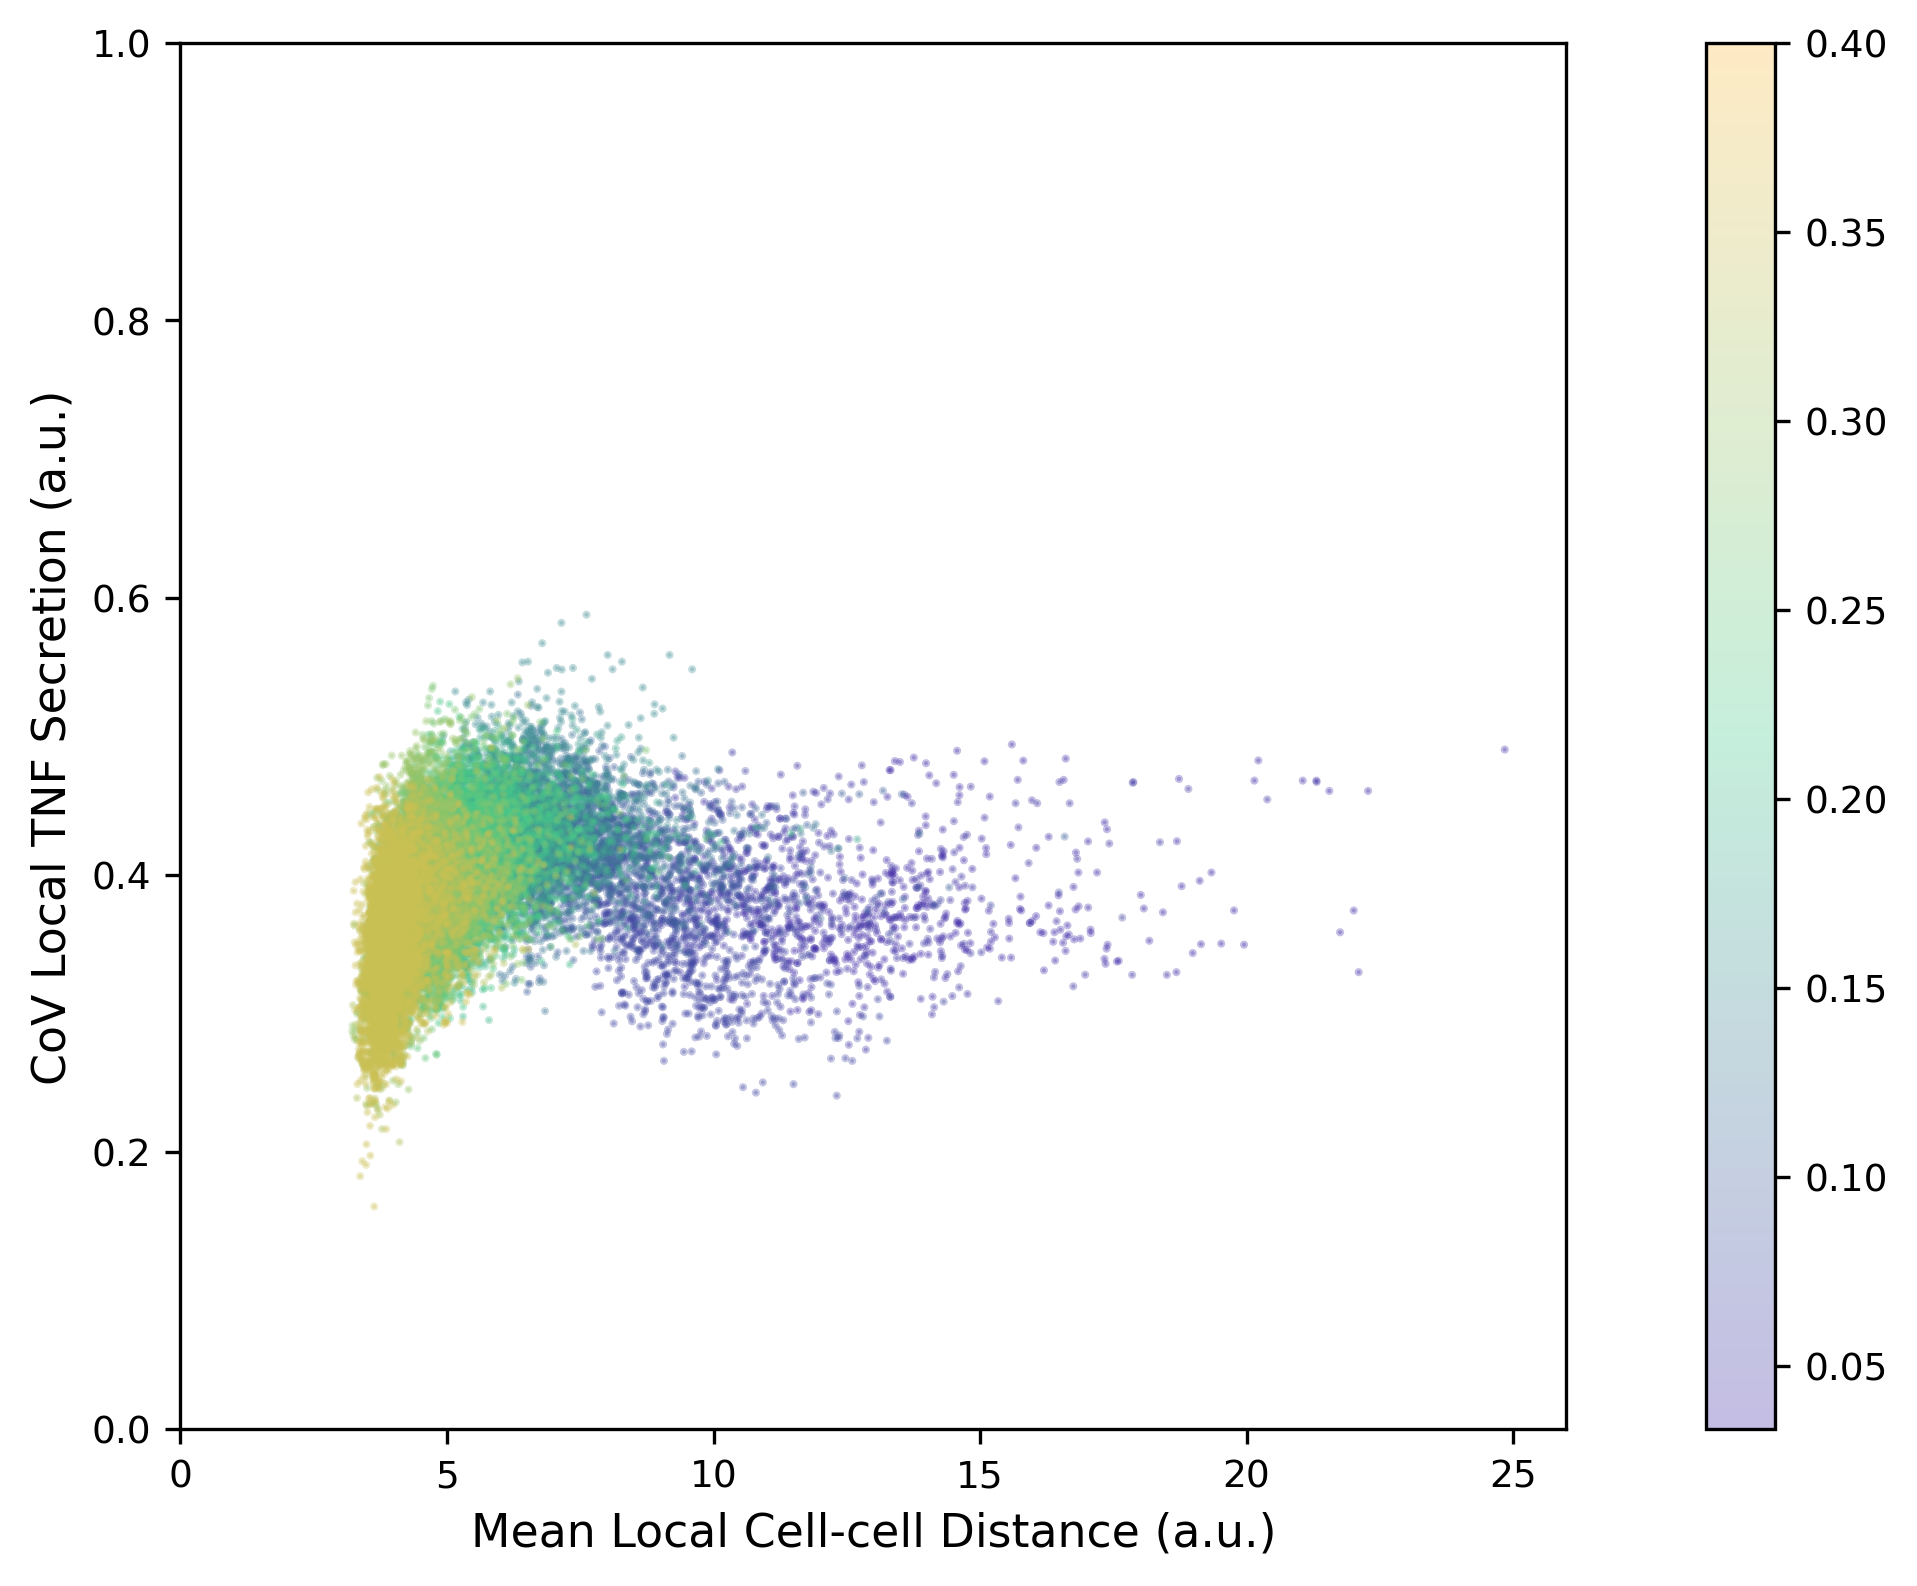

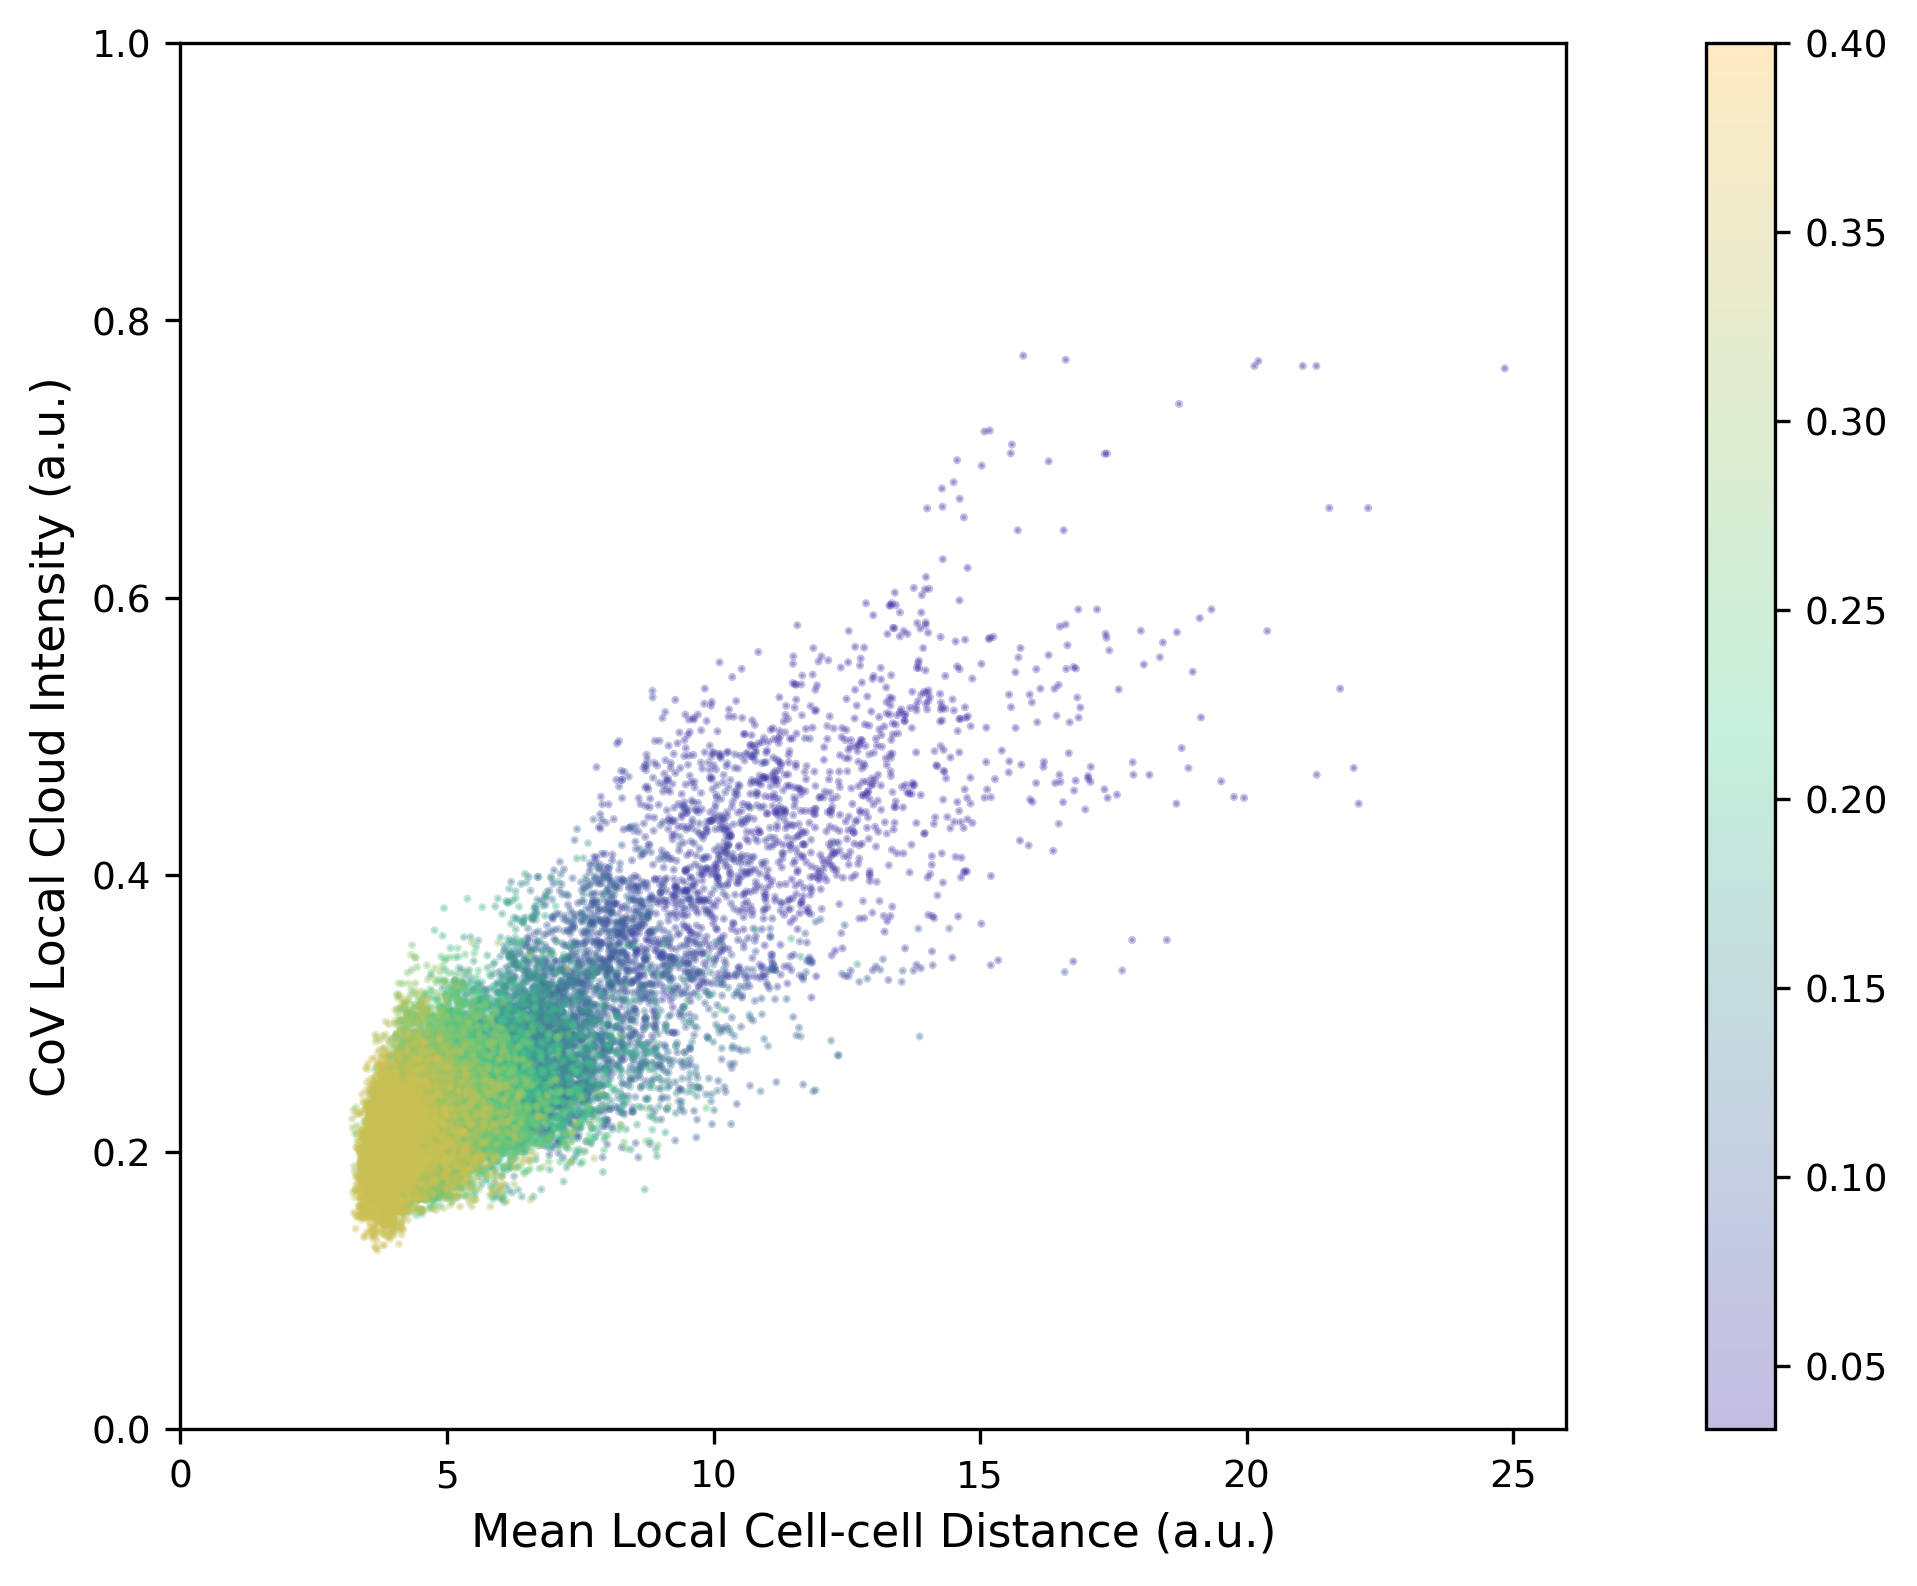

In [93]:
# select some densities to overlay on a single plot.
# strings must match how they occur in the filename.
levels_overlay_densities_l = ["0.0333", "0.05", "0.0667", "0.1", "0.125", "0.15", 
	"0.175", "0.2", "0.225", "0.25", "0.275", "0.30", "0.325", "0.35", "0.375", "0.40"]
cloud_overlay_densities_l = ["0.0333", "0.05", "0.0667", "0.1", "0.125", "0.15", 
	"0.175", "0.2", "0.225", "0.25", "0.275", "0.30", "0.325", "0.35", "0.375", "0.40"]

cloud_density_vals = [float(x) for x in cloud_overlay_densities_l]
levels_density_vals = [float(x) for x in levels_overlay_densities_l]

cloud_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
levels_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
plot_local_trends("", cloud_overlay_fig, levels_overlay_fig, n_neighbors=40)
plot.figure(cloud_overlay_fig)
plot.savefig("cloud.png")
plot.figure(levels_overlay_fig)
plot.savefig("levels.png")

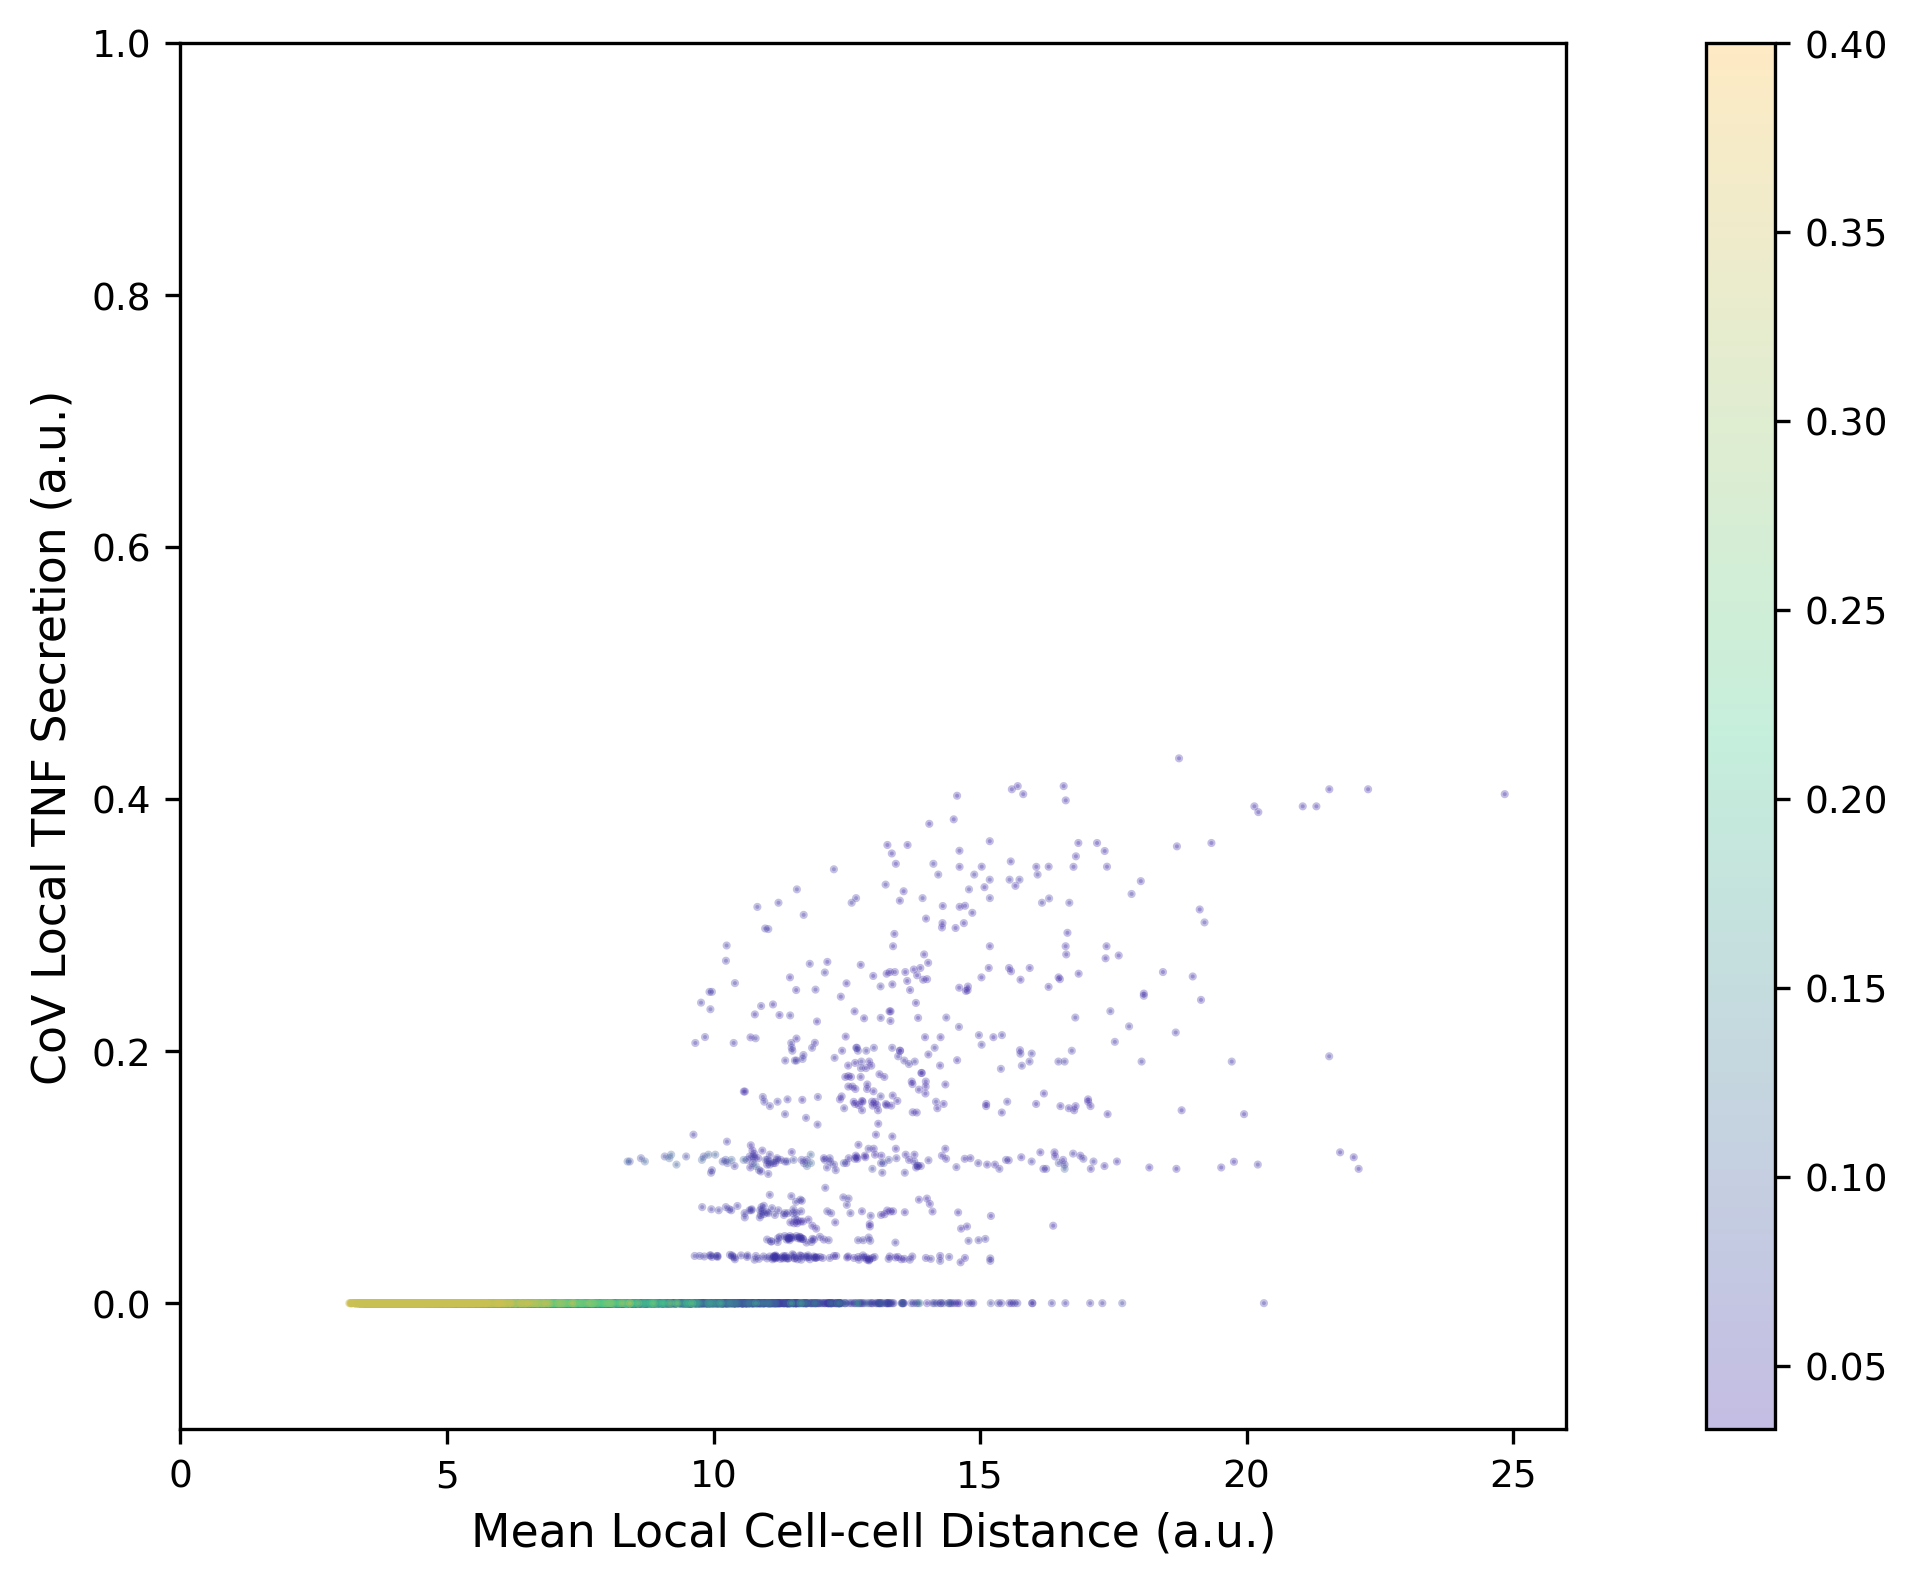

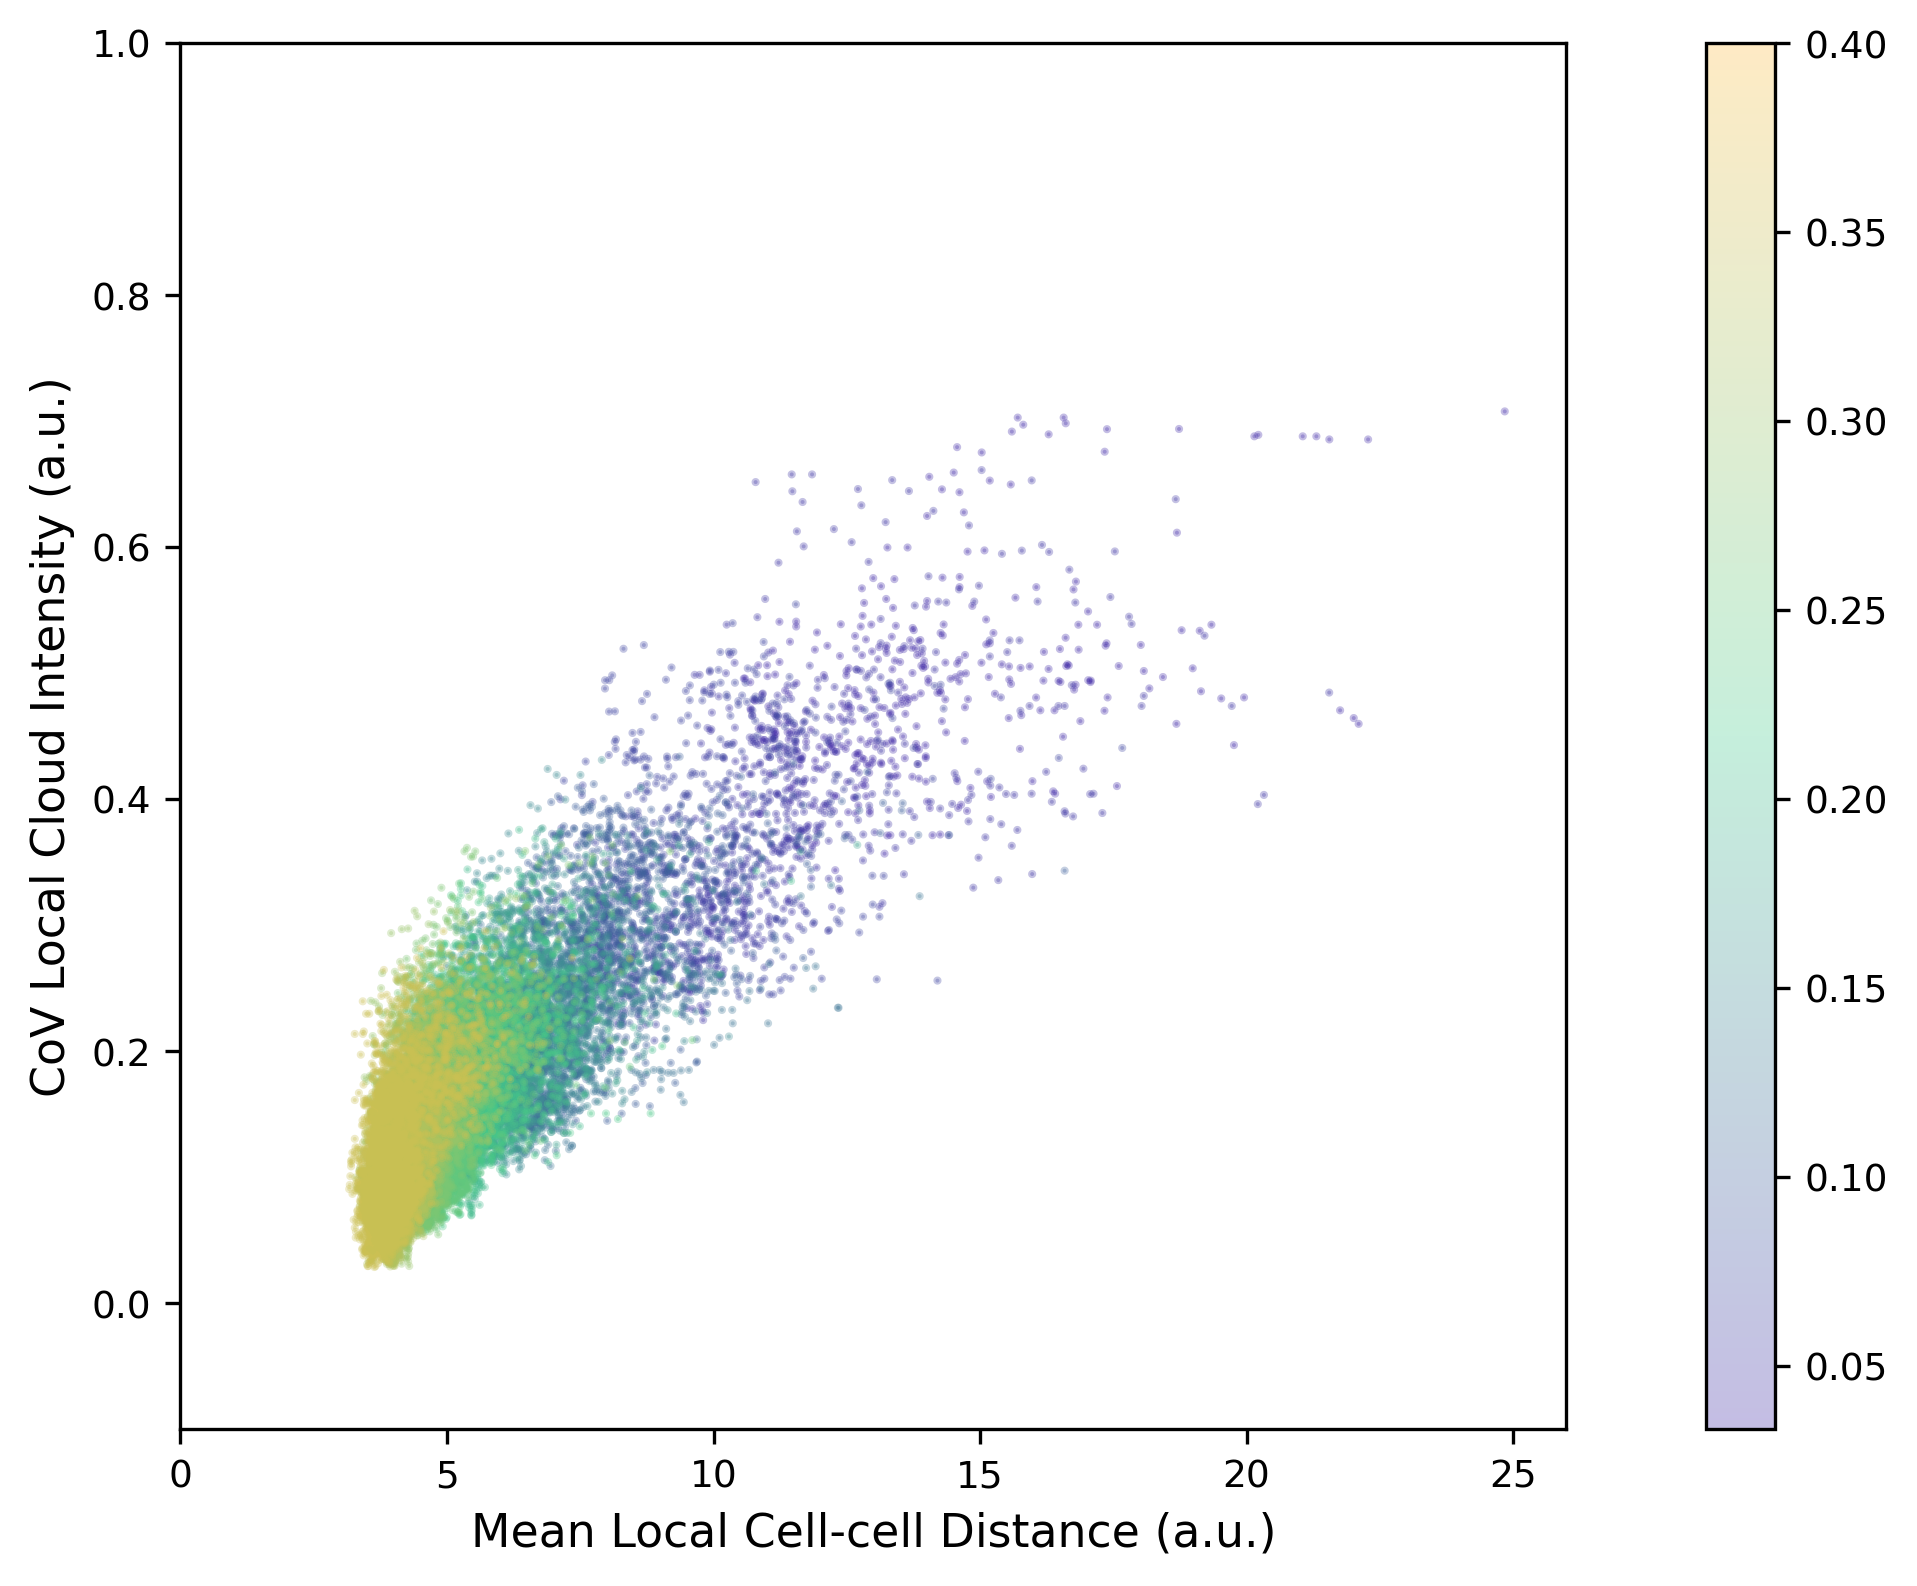

In [97]:
# select some densities to overlay on a single plot.
# strings must match how they occur in the filename.
levels_overlay_densities_l = ["0.0333", "0.05", "0.0667", "0.1", "0.125", "0.15", 
	"0.175", "0.2", "0.225", "0.25", "0.275", "0.30", "0.325", "0.35", "0.375", "0.40"]
cloud_overlay_densities_l = ["0.0333", "0.05", "0.0667", "0.1", "0.125", "0.15", 
	"0.175", "0.2", "0.225", "0.25", "0.275", "0.30", "0.325", "0.35", "0.375", "0.40"]

cloud_density_vals = [float(x) for x in cloud_overlay_densities_l]
levels_density_vals = [float(x) for x in levels_overlay_densities_l]

cloud_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
levels_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
plot_local_trends("noneg", cloud_overlay_fig, levels_overlay_fig, n_neighbors=40)
plot.figure(cloud_overlay_fig)
plot.savefig("cloud.png")
plot.figure(levels_overlay_fig)
plot.savefig("levels.png")